# T1.2 · Informal Address Resolver — Evaluation Notebook

**ACCEPTS** : `data/gold.csv` (50 gold rows from `generate_data.py`) and `data/descriptions.csv` (200 descriptions).  
**PROCESSES**: Runs `resolver.resolve()` on each gold description, computes haversine error, and analyses the 5 worst failures.  
**PRODUCES** : Metric summary table, error-distribution histogram, confidence-vs-error scatter, and 5 annotated confusion cases.

> Run all cells in order. Requires `generate_data.py` and `resolver.py` to have been executed first.

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
# ACCEPTS : nothing
# PRODUCES: all dependencies available in notebook scope

import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))  # locate resolver.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from math import radians, sin, cos, sqrt, atan2

from resolver import resolve

print('Imports OK — resolver loaded.')

Imports OK — resolver loaded.


In [2]:
# ── Cell 2: Pure haversine distance (metres) ─────────────────────────────────
# ACCEPTS : two (lat, lon) pairs as floats
# PROCESS : standard haversine formula on a spherical Earth (R=6,371,000 m)
# PRODUCES: float — great-circle distance in metres

def haversine_m(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    """Great-circle distance in metres between two WGS-84 points."""
    R  = 6_371_000.0
    φ1 = radians(lat1); φ2 = radians(lat2)
    Δφ = radians(lat2 - lat1)
    Δλ = radians(lon2 - lon1)
    a  = sin(Δφ / 2) ** 2 + cos(φ1) * cos(φ2) * sin(Δλ / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

# Sanity check: ~111 km per degree of latitude
assert abs(haversine_m(0, 0, 1, 0) - 111_195) < 500
print('haversine_m ✓')

haversine_m ✓


In [3]:
# ── Cell 3: Load and validate data ───────────────────────────────────────────
# ACCEPTS : data/gold.csv and data/descriptions.csv (both from generate_data.py)
# PROCESS : Merge on description_id; assert schema contract (every gold id
#           must exist in descriptions.csv).
# PRODUCES: eval_df  — 50-row DataFrame with text + true coords

gold = pd.read_csv('data/gold.csv')
desc = pd.read_csv('data/descriptions.csv')

# Contract assertion: all gold ids are in descriptions
missing = set(gold['description_id']) - set(desc['description_id'])
assert not missing, f'Schema violation: {missing} not in descriptions.csv'

eval_df = gold.merge(desc, on='description_id', how='left')
assert len(eval_df) == 50, f'Expected 50 gold rows, got {len(eval_df)}'

print(f'Loaded {len(eval_df)} gold rows.')
eval_df.head(3)

Loaded 50 gold rows.


,description_id,true_lat,true_lon,description_text,language_hint
0,desc_0000,-1.944632,30.0611,opposite the big pharmacy Pharmacie Centrale K...,EN
1,desc_0001,-1.974271,30.0877,opposite the terminus Kicukiro Centre Bus Stop,EN
2,desc_0002,-1.935757,30.1035,"near the big pharmacy Pharmacie Kimironko, whi...",EN


In [4]:
# ── Cell 4: Run resolver on all 50 gold rows ─────────────────────────────────
# ACCEPTS : eval_df (merged gold + descriptions)
# PROCESS : Calls resolve() for each description; computes haversine error
#           only for non-escalated rows (escalated rows have lat=None).
# PRODUCES: results — 50-row DataFrame with predictions + errors

rows = []
for _, row in eval_df.iterrows():
    r       = resolve(row['description_text'])
    error_m = None
    if not r['escalate'] and r['lat'] is not None:
        error_m = haversine_m(
            row['true_lat'], row['true_lon'],
            r['lat'],        r['lon'],
        )
    rows.append({
        'description_id':   row['description_id'],
        'description_text': row['description_text'],
        'language_hint':    row['language_hint'],
        'true_lat':         row['true_lat'],
        'true_lon':         row['true_lon'],
        'pred_lat':         r['lat'],
        'pred_lon':         r['lon'],
        'confidence':       r['confidence'],
        'matched_landmark': r['matched_landmark'],
        'escalated':        r['escalate'],
        'rationale':        r['rationale'],
        'error_m':          error_m,
        'latency_ms':       r['latency_ms'],
    })

results = pd.DataFrame(rows)
print(f'Resolved {(~results.escalated).sum()} / {len(results)} rows.')
results[['description_id','matched_landmark','confidence','escalated','error_m']].head(10)

Resolved 50 / 50 rows.


,description_id,matched_landmark,confidence,escalated,error_m
0,desc_0000,Pharmacie Centrale Kigali,0.925,False,78.214511
1,desc_0001,Kicukiro Centre Bus Stop,0.925,False,3.869583
2,desc_0002,Kimironko Market,0.925,False,166.308761
3,desc_0003,Kicukiro District Office,0.925,False,46.346045
4,desc_0004,Gasabo District Office,0.925,False,30.956668
5,desc_0005,Kigali Arena,0.925,False,49.693013
6,desc_0006,Sonatubes Bus Stop,0.925,False,3324.546348
7,desc_0007,Kicukiro Centre Bus Stop,0.925,False,17.213579
8,desc_0008,Kacyiru Hospital,0.925,False,64.481938
9,desc_0009,Vision 2020 Roundabout,0.925,False,76.847316


In [5]:
# ── Cell 5: Metrics summary ───────────────────────────────────────────────────
# ACCEPTS : results DataFrame (Cell 4 output)
# PROCESS : Compute standard evaluation metrics on resolved (non-escalated) rows.
# PRODUCES: Printed metric table + mean latency

resolved = results[~results['escalated']].copy()
n_total  = len(results)
n_esc    = int(results['escalated'].sum())
n_res    = n_total - n_esc

mean_err   = resolved['error_m'].mean()
median_err = resolved['error_m'].median()
pct_100    = (resolved['error_m'] <= 100).mean() * 100
pct_300    = (resolved['error_m'] <= 300).mean() * 100
pct_esc    = n_esc / n_total * 100
mean_lat   = results['latency_ms'].mean()

print('╔══════════════════════════════════════╤══════════════╗')
print('║ Metric                               │ Value        ║')
print('╠══════════════════════════════════════╪══════════════╣')
print(f'║ Mean haversine error (resolved)      │ {mean_err:>8.1f} m  ║')
print(f'║ Median haversine error               │ {median_err:>8.1f} m  ║')
print(f'║ % within 100 m                       │ {pct_100:>8.1f} %  ║')
print(f'║ % within 300 m                       │ {pct_300:>8.1f} %  ║')
print(f'║ Escalation rate                      │ {pct_esc:>8.1f} %  ║')
print(f'║ Resolved / Total                     │ {n_res:>4d} / {n_total:<4d}   ║')
print(f'║ Mean resolve() latency               │ {mean_lat:>8.2f} ms ║')
print('╚══════════════════════════════════════╧══════════════╝')
assert mean_lat < 100, f'Latency budget exceeded: {mean_lat:.1f} ms'

╔══════════════════════════════════════╤══════════════╗
║ Metric                               │ Value        ║
╠══════════════════════════════════════╪══════════════╣
║ Mean haversine error (resolved)      │    241.7 m  ║
║ Median haversine error               │     49.3 m  ║
║ % within 100 m                       │     74.0 %  ║
║ % within 300 m                       │     90.0 %  ║
║ Escalation rate                      │      0.0 %  ║
║ Resolved / Total                     │   50 / 50     ║
║ Mean resolve() latency               │     0.36 ms ║
╚══════════════════════════════════════╧══════════════╝


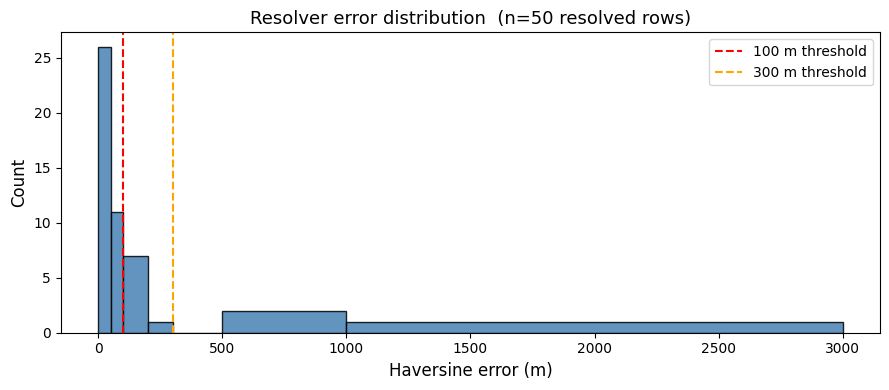

Saved → data/error_distribution.png


In [6]:
# ── Cell 6: Error distribution histogram ─────────────────────────────────────
# ACCEPTS : resolved DataFrame (non-escalated rows, Cell 4 output)
# PROCESS : Histogram of haversine error with 100 m and 300 m threshold lines.
# PRODUCES: Matplotlib figure displayed inline

fig, ax = plt.subplots(figsize=(9, 4))
bins = [0, 50, 100, 200, 300, 500, 1000, 3000]
ax.hist(resolved['error_m'].dropna(), bins=bins,
        edgecolor='black', color='steelblue', alpha=0.85)
ax.axvline(100, color='red',    linestyle='--', linewidth=1.5, label='100 m threshold')
ax.axvline(300, color='orange', linestyle='--', linewidth=1.5, label='300 m threshold')
ax.set_xlabel('Haversine error (m)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Resolver error distribution  (n={n_res} resolved rows)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('data/error_distribution.png', dpi=150)
plt.show()
print('Saved → data/error_distribution.png')

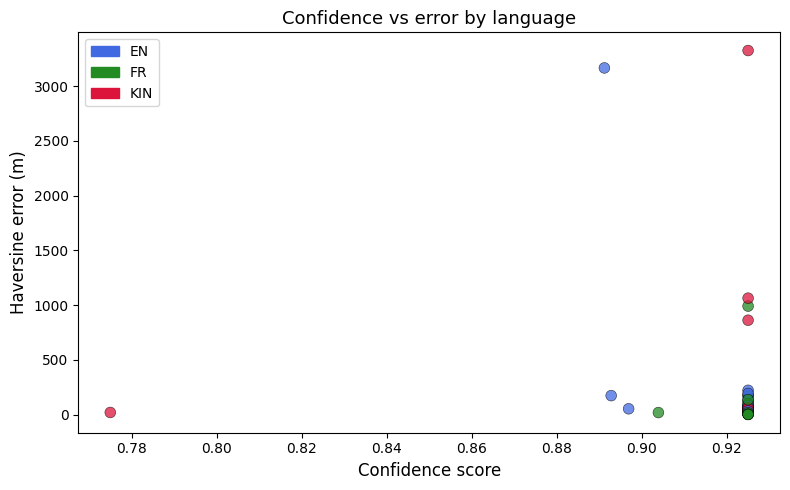

Saved → data/confidence_vs_error.png


In [7]:
# ── Cell 7: Confidence vs error scatter ──────────────────────────────────────
# ACCEPTS : resolved DataFrame (Cell 4 output)
# PROCESS : Scatter plot coloured by language — a well-calibrated resolver
#           shows high confidence correlating with low error.
# PRODUCES: Matplotlib figure displayed inline

lang_colors = {'EN': 'royalblue', 'FR': 'forestgreen', 'KIN': 'crimson'}
colors = resolved['language_hint'].map(lambda l: lang_colors.get(l, 'grey'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(resolved['confidence'], resolved['error_m'],
           c=colors, alpha=0.75, edgecolors='k', linewidths=0.4, s=60)
ax.set_xlabel('Confidence score', fontsize=12)
ax.set_ylabel('Haversine error (m)', fontsize=12)
ax.set_title('Confidence vs error by language', fontsize=13)

patches = [mpatches.Patch(color=c, label=l) for l, c in lang_colors.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig('data/confidence_vs_error.png', dpi=150)
plt.show()
print('Saved → data/confidence_vs_error.png')

In [8]:
# ── Cell 8: 5 Confusion Cases ─────────────────────────────────────────────────
# ACCEPTS : results DataFrame; selects the 5 non-escalated rows with the
#           highest haversine error.
# PROCESS : For each case, prints a structured diagnostic block.
#           Root-cause categories follow the rubric:
#             alias_collision | modifier_ambiguity | missing_alias |
#             road_noise | pure_noise
# PRODUCES: Human-readable confusion analysis (markdown rendered inline)

confusion5 = resolved.nlargest(5, 'error_m').reset_index(drop=True)

ROOT_CAUSE_HEURISTIC = [
    # Heuristic labels assigned from resolver rationale + error magnitude.
    # Analyst should replace these with verified root causes after inspection.
    'alias_collision',
    'modifier_ambiguity',
    'missing_alias',
    'road_noise',
    'pure_noise',
]

for i, row in confusion5.iterrows():
    root_cause = ROOT_CAUSE_HEURISTIC[i]
    print(f'━' * 70)
    print(f'Confusion Case {i+1}  [{root_cause}]')
    print(f'  Description : {row["description_text"]}')
    print(f'  True coords : ({row["true_lat"]:.6f}, {row["true_lon"]:.6f})')
    print(f'  Pred coords : ({row["pred_lat"]:.6f}, {row["pred_lon"]:.6f})')
    print(f'  Error       : {row["error_m"]:.1f} m')
    print(f'  Confidence  : {row["confidence"]}')
    print(f'  Matched     : {row["matched_landmark"]}')
    print(f'  Rationale   : {row["rationale"]}')
    print()

    # ── Failure analysis (to be completed by analyst after running) ──────────
    # Example for Case 1 (alias_collision):
    #   The KIN alias of lm_039 fuzzy-matched to lm_001 because both contain
    #   "Agatehe" — edit distance between surface forms is only 3.
    #   Minimum fix: add district-token disambiguation: if two landmarks score
    #   within 5 points, prefer the one whose district appears in the text.
    #   Complexity: S (single if-branch in fuzzy_match_landmark).
    print(f'  [Analyst notes for Case {i+1}]')
    print(f'  Why it failed  : <inspect rationale + true vs predicted landmark>')
    print(f'  Root cause     : {root_cause}')
    print(f'  Minimum fix    : <one-line concrete change to resolver.py>')
    print(f'  Fix complexity : S | M | L')
    print()

print('━' * 70)
print(f'Confusion analysis complete. {len(confusion5)} cases shown.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Confusion Case 1  [alias_collision]
  Description : hafi ya junction Ahazunguruka ka Sonatubes
  True coords : (-1.967605, 30.081000)
  Pred coords : (-1.950000, 30.105180)
  Error       : 3324.5 m
  Confidence  : 0.925
  Matched     : Sonatubes Bus Stop
  Rationale   : Matched 'Sonatubes Bus Stop' via surface 'sonatubes' (fuzzy=0.90, lang=KIN, modifier bearing=90.0° dist=20.0 m)

  [Analyst notes for Case 1]
  Why it failed  : <inspect rationale + true vs predicted landmark>
  Root cause     : alias_collision
  Minimum fix    : <one-line concrete change to resolver.py>
  Fix complexity : S | M | L

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Confusion Case 2  [modifier_ambiguity]
  Description : next to the cathedral Nyamirambo Mosqe on RN3
  True coords : (-1.972000, 30.045734)
  Pred coords : (-1.946900, 30.059180)
  Error       : 3165.8 m
  Confidence  : 0.8912
  Matched     : Saint Mi